# Convert Data Json ke Dataframe

In [61]:
# Library yang digunakan
import pandas as pd
import json

# Panggil file Json spotiff (listening history)
file = r"C:\Users\ACER\Downloads\StreamingHistory_music_0.json" # Ganti/Sesuaikan D dengan lokasi file "StreamingHistory_music_0.json" yang dimiliki
with open(file, 'r', encoding='utf-8') as f:
    data_history = json.load(f)

df_history = pd.DataFrame(data_history)
df_history

,endTime,artistName,trackName,msPlayed
0,2025-02-25 04:45,.Feast,"o,Tuan",305868
1,2025-02-25 04:49,.Feast,Peradaban,216682
2,2025-02-25 08:06,.Feast,Peradaban,7314
3,2025-02-25 08:06,Sheila On 7,Kita,2554
4,2025-02-25 08:09,The Panturas,All I Want,161174
...,...,...,...,...
4037,2026-02-24 08:58,Uncle Wire,Madu,282389
4038,2026-02-24 09:02,Fiji,Lonely Days,223051
4039,2026-02-24 09:05,Hendro Engkeng,Pas'pasan - Remastered 2024,198316
4040,2026-02-24 09:07,Fia,Love Me,111552


# Pengolahan Data

Text(0.5, 1.0, 'Top 10 Artists Yang Paling Sering Saya Dengar di Spotify')

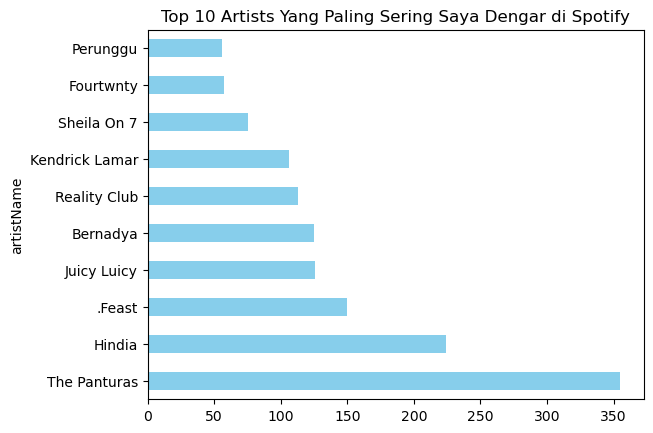

In [23]:
import matplotlib.pyplot as plt

# Top 10 Artists yang paling sering didengar
top_10_artists = df_history['artistName'].value_counts().head(10)
top_10_artists.plot(kind='barh', color='skyblue')
plt.title('Top 10 Artis Yang Paling Sering Saya Dengar di Spotify')


Text(0.5, 1.0, 'Top 10 Lagu Favorit')

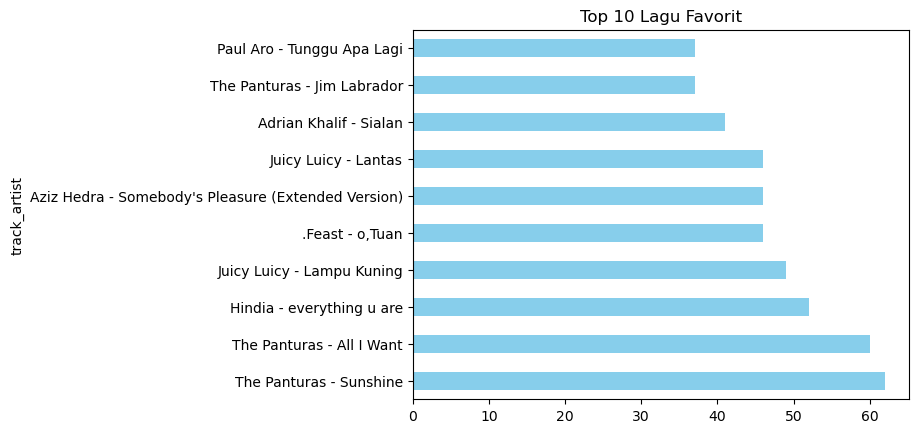

In [24]:
# Top 10 Lagu Yang Paling Sering didengar
df_history['track_artist'] = df_history['artistName'] + " - " + df_history['trackName']
top_10_songs = df_history['track_artist'].value_counts().head(10)
top_10_songs.plot(kind='barh', color='skyblue')
plt.title('Top 10 Lagu Favorit')

In [48]:
# Eksplorasi lagu-lagu didalam playlist yang sering diskip
df_history['skip'] = df_history['msPlayed'] < 30000 #Ini 30 detik
skipped = df_history.groupby('artistName')['skip'].mean().sort_values(ascending=False).head(100)
skipped = skipped.reset_index()
skipped['skip_percentage'] = (skipped['skip'] * 100).round(1)

print(skipped)

                   artistName      skip  skip_percentage
0   落日飛車 Sunset Rollercoaster  1.000000            100.0
1                  Leal Fvnky  1.000000            100.0
2                    The Cure  1.000000            100.0
3             The Cranberries  1.000000            100.0
4                       Mahen  1.000000            100.0
..                        ...       ...              ...
95                    HUNTR/X  0.333333             33.3
96                 Rio Clappy  0.333333             33.3
97                 Juice WRLD  0.333333             33.3
98               Henry Moodie  0.333333             33.3
99                The Beatles  0.333333             33.3

[100 rows x 3 columns]


22:24:45 - cmdstanpy - INFO - Chain [1] start processing
22:24:45 - cmdstanpy - INFO - Chain [1] done processing


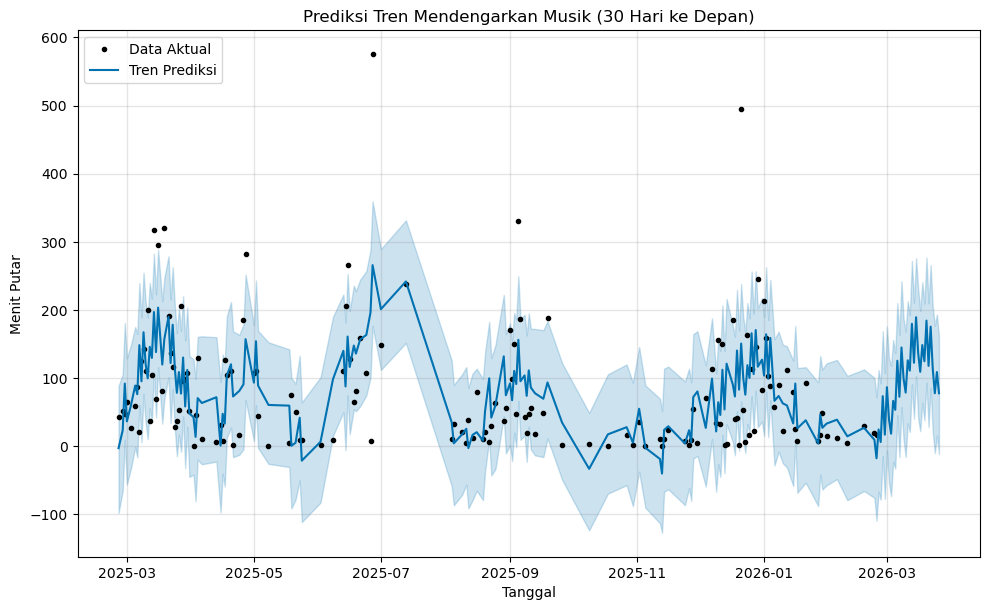

In [69]:
# Prediksi tren mendengarkan musik 30 hari kedepan
from prophet import Prophet
import matplotlib.pyplot as plt

# Convert data waktu dan tanggal
df_history['endTime'] = pd.to_datetime(df_history['endTime'])
df_history['date_only'] = df_history['endTime'].dt.date
df_history['minutesPlayed'] = df_history['msPlayed'] / 60000

# Mengumpulkan data menjadi mendengarkan musik berdasarkan hari 
daily_trend = df_history.groupby('date_only')['minutesPlayed'].sum().reset_index()
daily_trend.columns = ['ds', 'y']

# Melatih Model prediksi prophet
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(daily_trend)

# Prediksi model 30 hari kedepan (dari tanggal 2 Maret 2026)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Visualisasi Hasil Prediksi
fig1 = model.plot(forecast)
plt.legend(['Data Aktual', 'Tren Prediksi',], 
           loc='upper left', fontsize=10)
plt.title('Prediksi Tren Mendengarkan Musik (30 Hari ke Depan)')
plt.xlabel('Tanggal')
plt.ylabel('Menit Putar')
plt.show()

plt.show()